In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.

C:\Users\afrin\AppData\Local\Temp\ipykernel_22420\3778388593.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=data, palette='coolwarm')


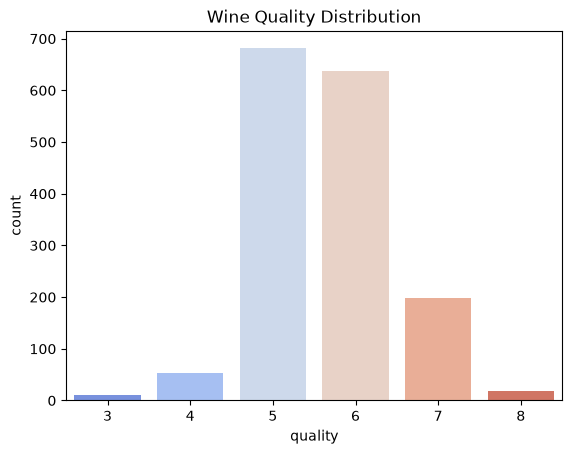

In [3]:
data = pd.read_csv('winequality-red.csv', sep=';')
print(data.info())
print(data.describe())
print(data.head())

sns.countplot(x='quality', data=data, palette='coolwarm')
plt.title('Wine Quality Distribution')
plt.show()

In [4]:
data['quality_label'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)
data.drop('quality', axis=1, inplace=True)

X = data.drop('quality_label', axis=1)
y = data['quality_label']

print("Class distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

Class distribution:
 quality_label
0    1382
1     217
Name: count, dtype: int64


In [5]:
lr_model = LogisticRegression()
lr_model.fit(X_train_lr, y_train)
y_pred_lr = lr_model.predict(X_test_lr)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


--- Logistic Regression ---
Accuracy: 0.89375

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



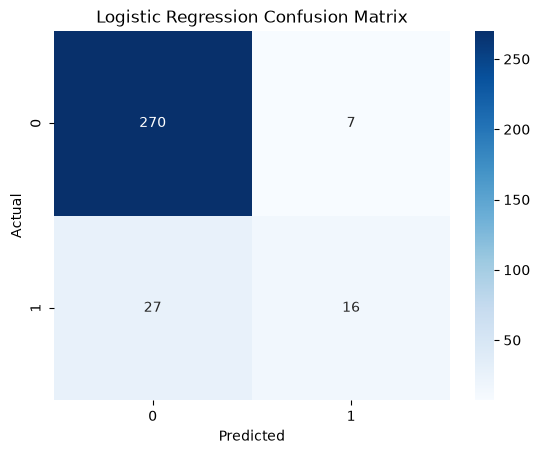


--- Random Forest ---
Accuracy: 0.94375

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       277
           1       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320



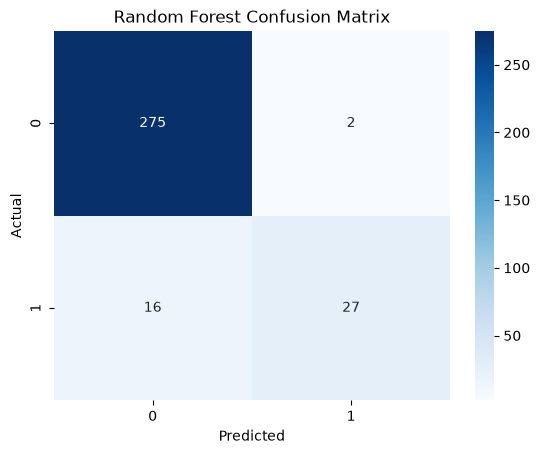

In [6]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

In [7]:
data_white = pd.read_csv('winequality-white.csv', sep=';')
data_white['quality_label'] = data_white['quality'].apply(lambda x: 1 if x >= 7 else 0)
data_white.drop('quality', axis=1, inplace=True)

X_white = data_white.drop('quality_label', axis=1)
y_white = data_white['quality_label']

print("White wine class distribution:\n", y_white.value_counts())

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white
)

scaler_w = StandardScaler()
X_train_w_lr = scaler_w.fit_transform(X_train_w)
X_test_w_lr = scaler_w.transform(X_test_w)

White wine class distribution:
 quality_label
0    3838
1    1060
Name: count, dtype: int64


In [8]:
lr_model_white = LogisticRegression()
lr_model_white.fit(X_train_w_lr, y_train_w)
y_pred_lr_white = lr_model_white.predict(X_test_w_lr)

rf_model_white = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_white.fit(X_train_w, y_train_w)
y_pred_rf_white = rf_model_white.predict(X_test_w)


--- Logistic Regression (White Wine) ---
Accuracy: 0.8010204081632653

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.88       768
           1       0.58      0.28      0.38       212

    accuracy                           0.80       980
   macro avg       0.71      0.61      0.63       980
weighted avg       0.77      0.80      0.77       980



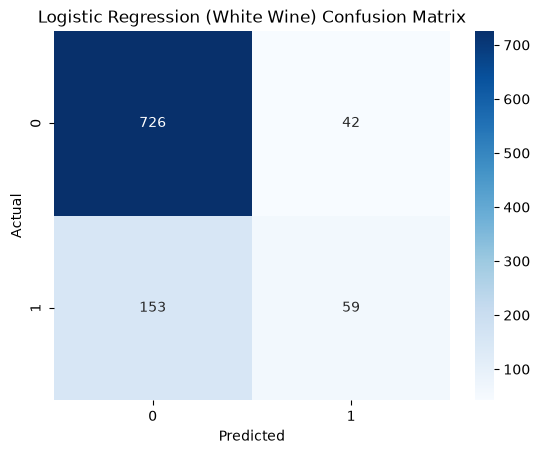


--- Random Forest (White Wine) ---
Accuracy: 0.8908163265306123

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93       768
           1       0.81      0.64      0.72       212

    accuracy                           0.89       980
   macro avg       0.86      0.80      0.82       980
weighted avg       0.89      0.89      0.89       980



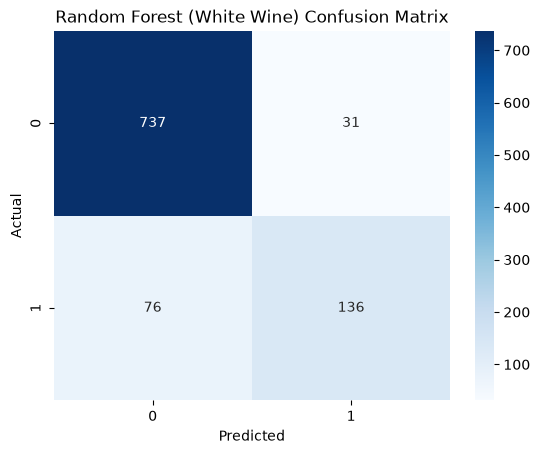

In [9]:
evaluate_model(y_test_w, y_pred_lr_white, "Logistic Regression (White Wine)")
evaluate_model(y_test_w, y_pred_rf_white, "Random Forest (White Wine)")

In [10]:
import joblib

joblib.dump(rf_model, 'rf_model_red.pkl')
joblib.dump(scaler, 'scaler_red.pkl')

joblib.dump(rf_model_white, 'rf_model_white.pkl')
joblib.dump(scaler_w, 'scaler_white.pkl')

print("Models saved successfully.")

Models saved successfully.


In [11]:
loaded_rf_red = joblib.load('rf_model_red.pkl')

sample = X_test.iloc[[0]]
prediction = loaded_rf_red.predict(sample)
actual = y_test.iloc[0]

print("Predicted:", prediction[0])
print("Actual:", actual)

Predicted: 0
Actual: 0
